In [2]:
import streamlit as st
import pandas as pd
import numpy as np
import plotly.express as px
from plotly.subplots import make_subplots
import plotly.graph_objects as go
import matplotlib.pyplot as plt
from datetime import datetime as dt

In [3]:
import folium
from folium.plugins import AntPath
import branca.colormap as cm

In [4]:
df=pd.read_parquet("df.parquet")

### Most popular stations

In [5]:
station_counts=(
    df["start_station_name"]
    .value_counts()
    .reset_index()
)

station_counts.columns = ["station", "trip_count"]

top_stations=station_counts.head(20)

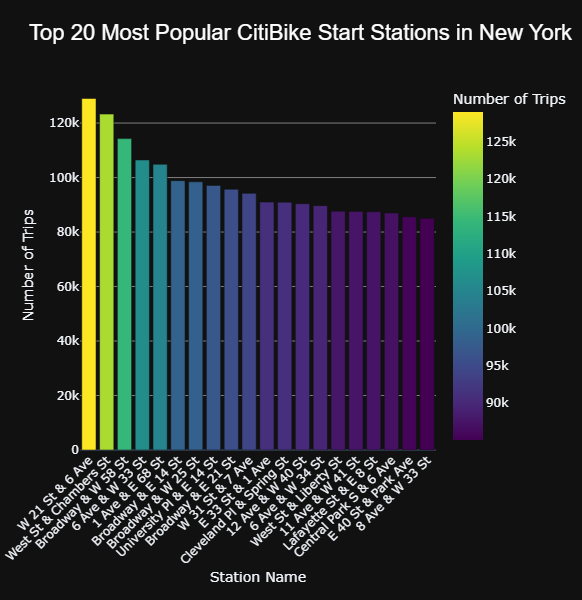

In [6]:
#plotting bar chart with plotly

fig=px.bar(
    top_stations,
    x="station",
    y="trip_count",
    title="Top 20 Most Popular CitiBike Start Stations in New York",
    labels={"station": "Station Name", "trip_count": "Number of Trips"},
    color="trip_count",
    hover_data={"station": True, "trip_count": True}, #adding hovering option
    color_continuous_scale="Viridis"
)

fig.update_layout(
    template="plotly_dark",   #personal preference for clean and professional look
    title_font=dict(size=22, family="Arial", color="white"),
    xaxis_tickangle=-45,
    xaxis=dict(showgrid=False),
    yaxis=dict(showgrid=True, gridcolor="gray"),
    height=600,
    margin=dict(l=60, r=40, t=80, b=150)
)

fig.show()

### Dual-axis chart

In [7]:
df.columns

Index(['ride_id', 'rideable_type', 'started_at', 'ended_at',
       'start_station_name', 'start_station_id', 'end_station_name',
       'end_station_id', 'start_lat', 'start_lng', 'end_lat', 'end_lng',
       'member_casual', 'date', 'avgTemp', 'trips', 'tripduration'],
      dtype='object')

In [8]:
df.head()

,ride_id,rideable_type,started_at,ended_at,start_station_name,start_station_id,end_station_name,end_station_id,start_lat,start_lng,end_lat,end_lng,member_casual,date,avgTemp,trips,tripduration
0,291C8B1D2F451F20,classic_bike,2022-01-01 01:41:45.865,2022-01-01 02:19:07.819,Central Park West & W 76 St,7253.04,5 Ave & E 78 St,7161.08,40.778968,-73.973747,40.776321,-73.964274,casual,2022-01-01,2.0,20428,37.365900
1,EE55558726CC75A7,classic_bike,2022-01-01 03:39:20.314,2022-01-01 03:47:43.294,E 88 St & 1 Ave,7235.13,5 Ave & E 87 St,7323.09,40.778301,-73.948813,40.782323,-73.959875,casual,2022-01-01,2.0,20428,8.383000
2,BAE74126E17B6794,electric_bike,2022-01-01 17:33:03.958,2022-01-01 17:43:13.897,Metropolitan Ave & Bedford Ave,5308.04,Montrose Ave & Bushwick Ave,5068.02,40.715348,-73.960241,40.707678,-73.940162,casual,2022-01-01,2.0,20428,10.165650
3,F4151B16DDFE3052,classic_bike,2022-01-01 14:31:52.691,2022-01-01 14:54:30.877,W 21 St & 6 Ave,6140.05,West End Ave & W 60 St,7059.08,40.741740,-73.994156,40.772370,-73.990050,member,2022-01-01,2.0,20428,22.636433
4,E87EDCD278436C83,classic_bike,2022-01-01 14:52:25.593,2022-01-01 15:12:10.330,5 Ave & E 87 St,7323.09,Frederick Douglass Blvd & W 117 St,7688.12,40.782323,-73.959875,40.805159,-73.954692,member,2022-01-01,2.0,20428,19.745617


In [9]:
df_small=df.sample(n=10000, random_state=42)

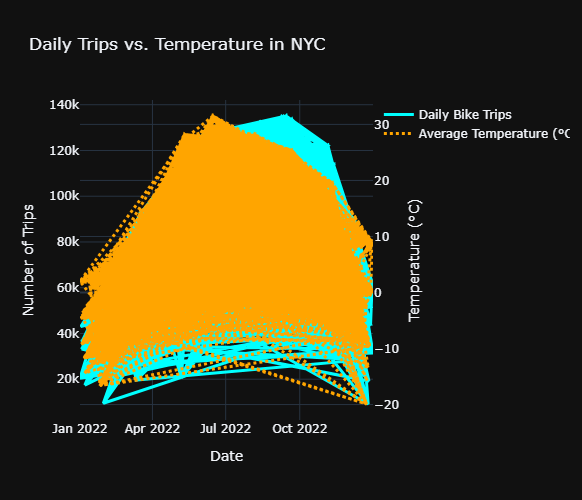

In [10]:
#dual-axis plotting in celsius

fig=go.Figure()

fig.add_trace(
    go.Scatter(
        x=df_small["date"],
        y=df_small["trips"],
        mode="lines",
        name="Daily Bike Trips",
        line=dict(color="cyan", width=3)
    )
)

fig.add_trace(
    go.Scatter(
        x=df_small["date"],
        y=df_small["avgTemp"],
        mode="lines",
        name="Average Temperature (°C)",
        line=dict(color="orange", width=3, dash="dot"),
        yaxis="y2"
    )
)

fig.update_layout(
    title="Daily Trips vs. Temperature in NYC",
    xaxis_title="Date",
    yaxis_title="Number of Trips",
    yaxis2=dict(
        title="Temperature (°C)",
        overlaying="y",
        side="right"
    ),
    template="plotly_dark",
    legend=dict(
        bgcolor="rgba(0,0,0,0)",
        bordercolor="rgba(0,0,0,0)"
    ),
    height=500
)

fig.show()

In [11]:
#creating month column for better readability

df_small['month']=pd.to_datetime(df_small['date']).dt.to_period('M').dt.to_timestamp()

In [12]:
#aggregating trips 

monthly_trips=df_small.groupby('month')['trips'].sum().reset_index()
monthly_temp=df_small.groupby('month')['avgTemp'].mean().reset_index()

monthly=monthly_trips.merge(monthly_temp, on='month')

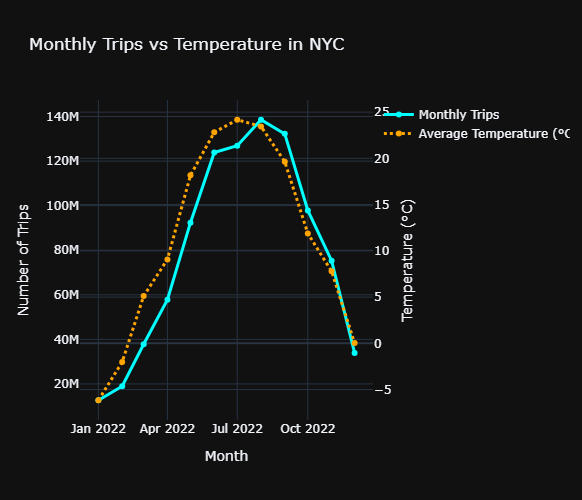

In [13]:
#cleaner plot by months

fig = go.Figure()

fig.add_trace(go.Scatter(
    x=monthly['month'],
    y=monthly['trips'],
    name='Monthly Trips',
    mode='lines+markers',
    line=dict(color='cyan', width=3)
))

fig.add_trace(go.Scatter(
    x=monthly['month'],
    y=monthly['avgTemp'],
    name='Average Temperature (°C)',
    mode='lines+markers',
    line=dict(color='orange', width=3, dash='dot'),
    yaxis='y2'
))

fig.update_layout(
    title='Monthly Trips vs Temperature in NYC',
    template='plotly_dark',
    xaxis_title='Month',
    yaxis_title='Number of Trips',
    yaxis2=dict(
        title='Temperature (°C)',
        overlaying='y',
        side='right'
    ),
    legend=dict(
        bgcolor='rgba(0,0,0,0)',
        borderwidth=0
    ),
    height=500
)

fig.show()

In [15]:
df_small.to_parquet("df_small.parquet")